## part 3: analysis/ figures from random sampled TC data

In [1]:
!pip uninstall dea-tools -y

In [2]:
%pip install ultraplot -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import datacube
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import ultraplot as uplt
import cartopy.crs as ccrs
from matplotlib.dates import MonthLocator, DateFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from datacube.utils import masking
from scipy.stats import linregress
import calendar
import warnings
import time
import odc.geo.xr
from odc.geo.geom import Geometry, CRS
from shapely.geometry import box

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from math import sqrt



from odc.algo._percentile import xr_quantile_bands

import sys

sys.path.insert(1, "../../../Tools")
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.dask import create_local_dask_cluster
from dea_tools.bandindices import calculate_indices
from dea_tools.spatial import add_geobox

warnings.filterwarnings("ignore")


### This version of the notebook reads in the .csv files from random sampled points across AU



In [4]:
def bias(x, y):
    return np.mean(x - y)


In [5]:
def add_arrow(head_pos, tail_pos, ax):
    style = "Simple, tail_width=0.01, head_width=1, head_length=2"
    kw = dict(arrowstyle=style, color="k", linewidth=0.2)
    arrow = patches.FancyArrowPatch(
        tail_pos, head_pos,
        connectionstyle="arc3,rad=.5",
        **kw
    )
    ax.add_patch(arrow)

In [6]:
csv_files = glob.glob('temp_outputs/*.csv')

colnames = [
    'class', 'TCW', 'TCB', 'TCG', 'TCW_DEA', 
    'TCB_DEA', 'TCG_DEA', 'TCW_ls8', 'TCB_ls8', 'TCG_ls8'
]

dfs = []
for file in csv_files:
    classname = file.split('_')[3]
    df = pd.read_csv(file, usecols=colnames)
    df['classname'] = classname
    dfs.append(df)
    df['class'] = df['class'].astype(int)

cdf = pd.concat(dfs, ignore_index=True)
#cdf = cdf.drop(columns='class')

In [8]:
cdf

,class,TCW,TCG,TCB,TCW_DEA,TCB_DEA,TCG_DEA,TCW_ls8,TCB_ls8,TCG_ls8,classname
0,40,-0.343292,0.015310,0.334093,-0.186755,0.528521,-0.054765,-0.250793,0.518441,0.007040,cropland
1,40,-0.335815,0.055465,0.339959,-0.209164,0.530078,-0.029725,-0.239276,0.521131,0.046413,cropland
2,40,-0.303964,0.039052,0.332728,-0.170835,0.498799,-0.017462,-0.220038,0.492230,0.032349,cropland
3,40,-0.310137,0.052373,0.420295,-0.178643,0.591218,-0.002329,-0.211767,0.586026,0.041634,cropland
4,40,-0.342098,0.018366,0.329182,-0.206729,0.518070,-0.063427,-0.251150,0.513022,0.011868,cropland
...,...,...,...,...,...,...,...,...,...,...,...
3423,10,-0.175783,0.098484,0.245872,-0.130520,0.342281,0.050894,-0.113474,0.338817,0.091035,tree
3424,10,-0.212086,0.050497,0.253970,-0.138375,0.375600,-0.004636,-0.143110,0.370891,0.041860,tree
3425,10,-0.147096,0.106578,0.212736,-0.124534,0.292592,0.057866,-0.091977,0.290611,0.099988,tree
3426,10,-0.130936,0.099263,0.206566,-0.107051,0.277987,0.060440,-0.079542,0.275880,0.092394,tree


In [9]:
for col in cdf.columns[1:4]:
    cdf[f'diff_{col}_DEA'] = cdf[col] - cdf[f'{col}_DEA']
    cdf[f'diff_{col}_ls8'] = cdf[col] - cdf[f'{col}_ls8']
    

In [10]:
variable_pairs = {
    "baig_l8": [("TCW", "TCW_ls8"), ("TCG", "TCG_ls8"), ("TCB", "TCB_ls8")],
    "DEA_l8": [("TCW", "TCW_DEA"), ("TCG", "TCG_DEA"), ("TCB", "TCB_DEA")],
}

worldcover_class_list = list(cdf['classname'].unique())

In [11]:
worldcover_class_list

['cropland',
 'grassland',
 'wetland',
 'shrubland',
 'mangroves',
 'water',
 'built-up',
 'bare',
 'tree']

In [12]:
cdf.head()

,class,TCW,TCG,TCB,TCW_DEA,TCB_DEA,TCG_DEA,TCW_ls8,TCB_ls8,TCG_ls8,classname,diff_TCW_DEA,diff_TCW_ls8,diff_TCG_DEA,diff_TCG_ls8,diff_TCB_DEA,diff_TCB_ls8
0,40,-0.343292,0.015310,0.334093,-0.186755,0.528521,-0.054765,-0.250793,0.518441,0.007040,cropland,-0.156537,-0.092499,0.070075,0.008270,-0.194428,-0.184348
1,40,-0.335815,0.055465,0.339959,-0.209164,0.530078,-0.029725,-0.239276,0.521131,0.046413,cropland,-0.126651,-0.096539,0.085190,0.009052,-0.190119,-0.181172
2,40,-0.303964,0.039052,0.332728,-0.170835,0.498799,-0.017462,-0.220038,0.492230,0.032349,cropland,-0.133129,-0.083926,0.056514,0.006703,-0.166071,-0.159502
3,40,-0.310137,0.052373,0.420295,-0.178643,0.591218,-0.002329,-0.211767,0.586026,0.041634,cropland,-0.131494,-0.098370,0.054702,0.010739,-0.170923,-0.165731
4,40,-0.342098,0.018366,0.329182,-0.206729,0.518070,-0.063427,-0.251150,0.513022,0.011868,cropland,-0.135369,-0.090948,0.081793,0.006498,-0.188888,-0.183840


In [13]:
#Calculate RMSE, MAI and bias for each pixel/timestep
error_metrics_results = []

for i, group in variable_pairs.items():
    print(group)
    for j, (var1, var2) in enumerate(group):
        for cls, group in cdf.groupby('classname'):
            rmse = root_mean_squared_error(group[var1], group[var2])
            mae = mean_absolute_error(group[var1], group[var2])
            vbias = bias(group[var1].values, group[var2].values)
            error_metrics_results.append({
                'TC': var2, 'class': cls, 'RMSE': rmse, 'MAE': mae, 'bias': vbias
            })

error_metrics_df = pd.DataFrame(error_metrics_results)

[('TCW', 'TCW_ls8'), ('TCG', 'TCG_ls8'), ('TCB', 'TCB_ls8')]
[('TCW', 'TCW_DEA'), ('TCG', 'TCG_DEA'), ('TCB', 'TCB_DEA')]


In [14]:
error_metrics_df.head()

,TC,class,RMSE,MAE,bias
0,TCW_ls8,bare,0.113000,0.108429,-0.108429
1,TCW_ls8,built-up,0.076093,0.074825,-0.074825
2,TCW_ls8,cropland,0.087272,0.085837,-0.085837
3,TCW_ls8,grassland,0.095555,0.093133,-0.093133
4,TCW_ls8,mangroves,0.049975,0.049175,-0.049175


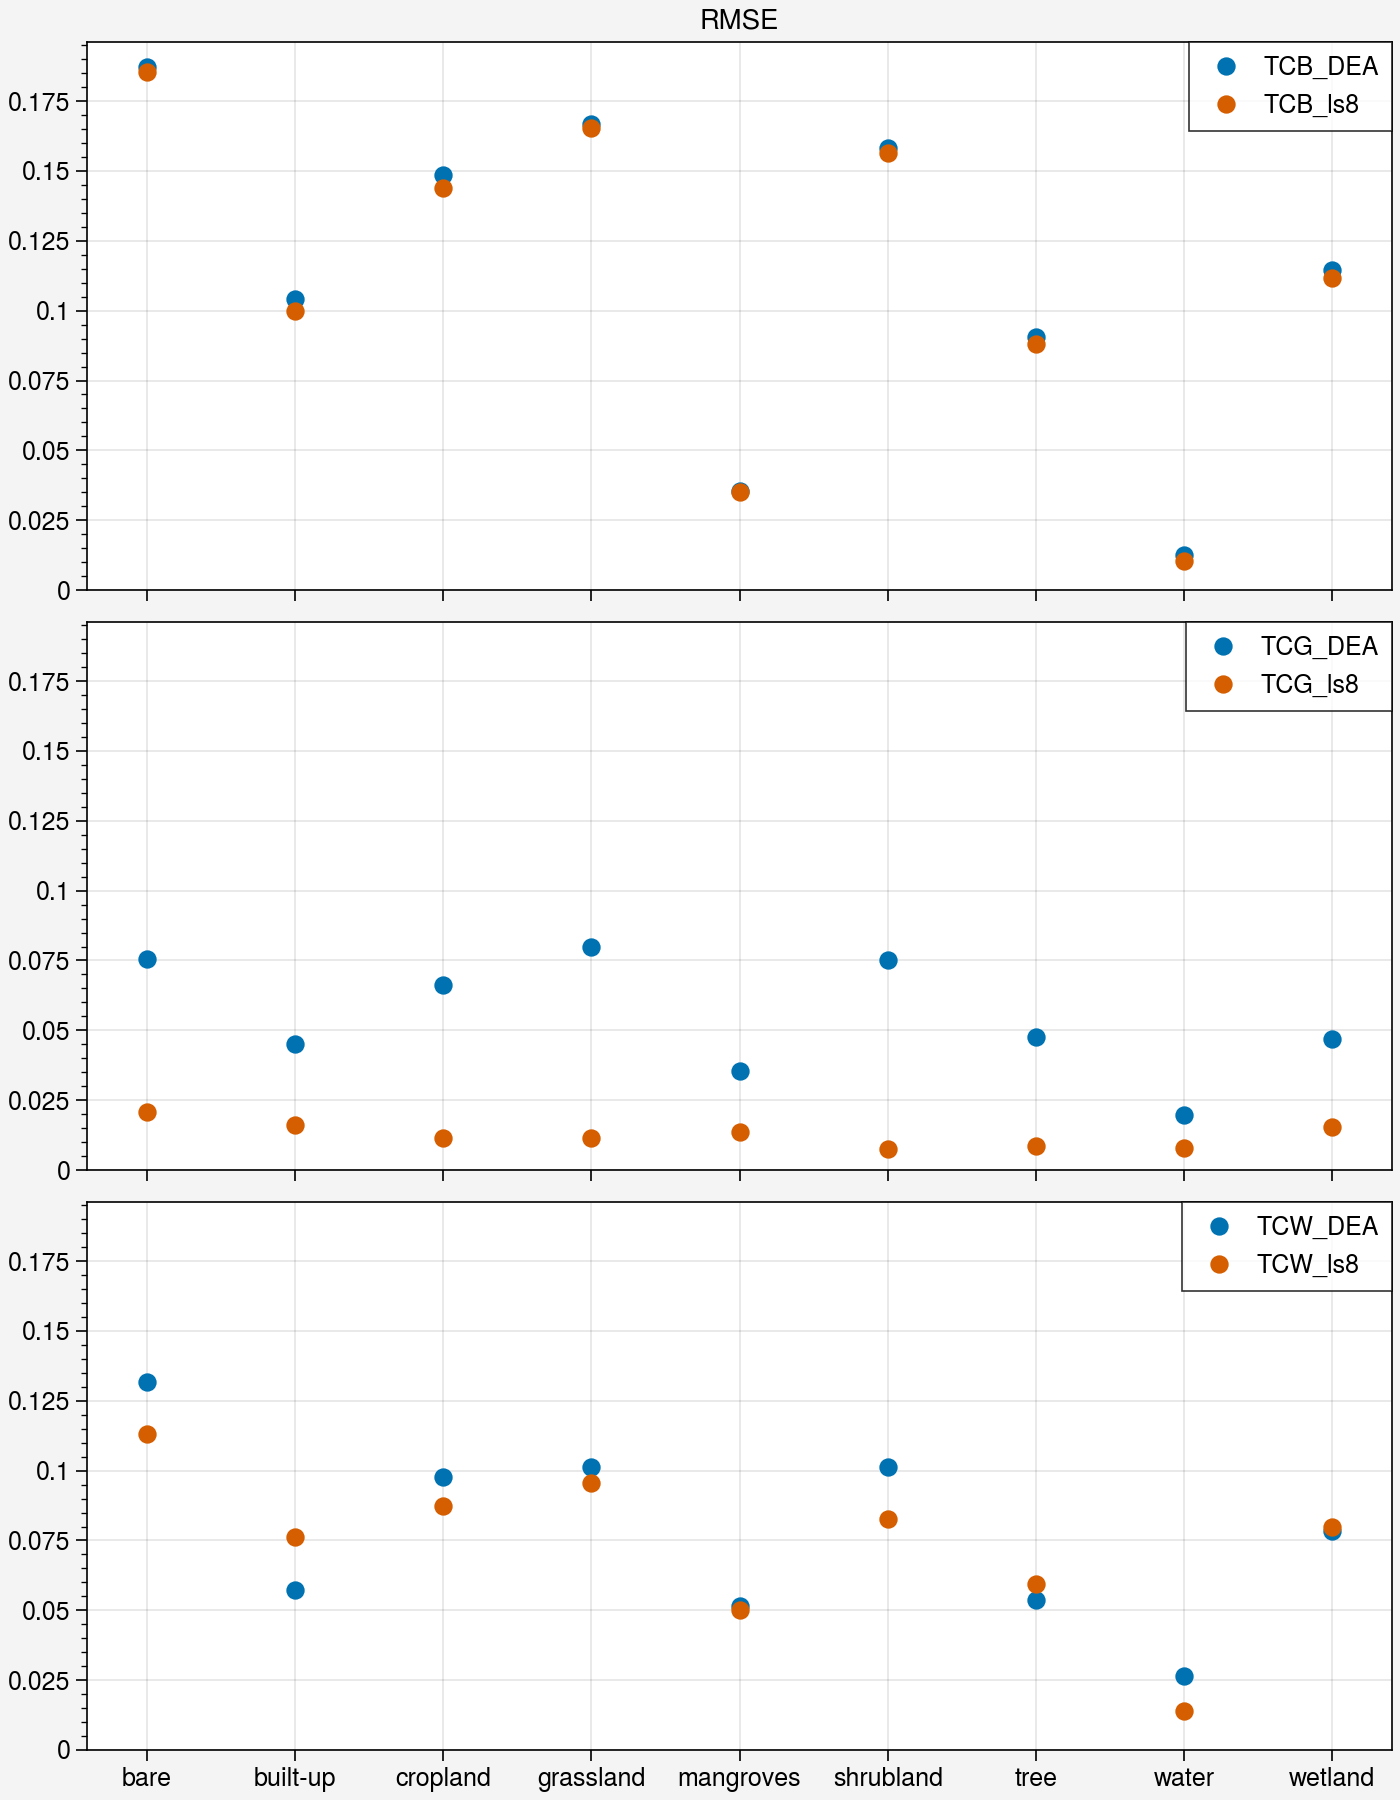

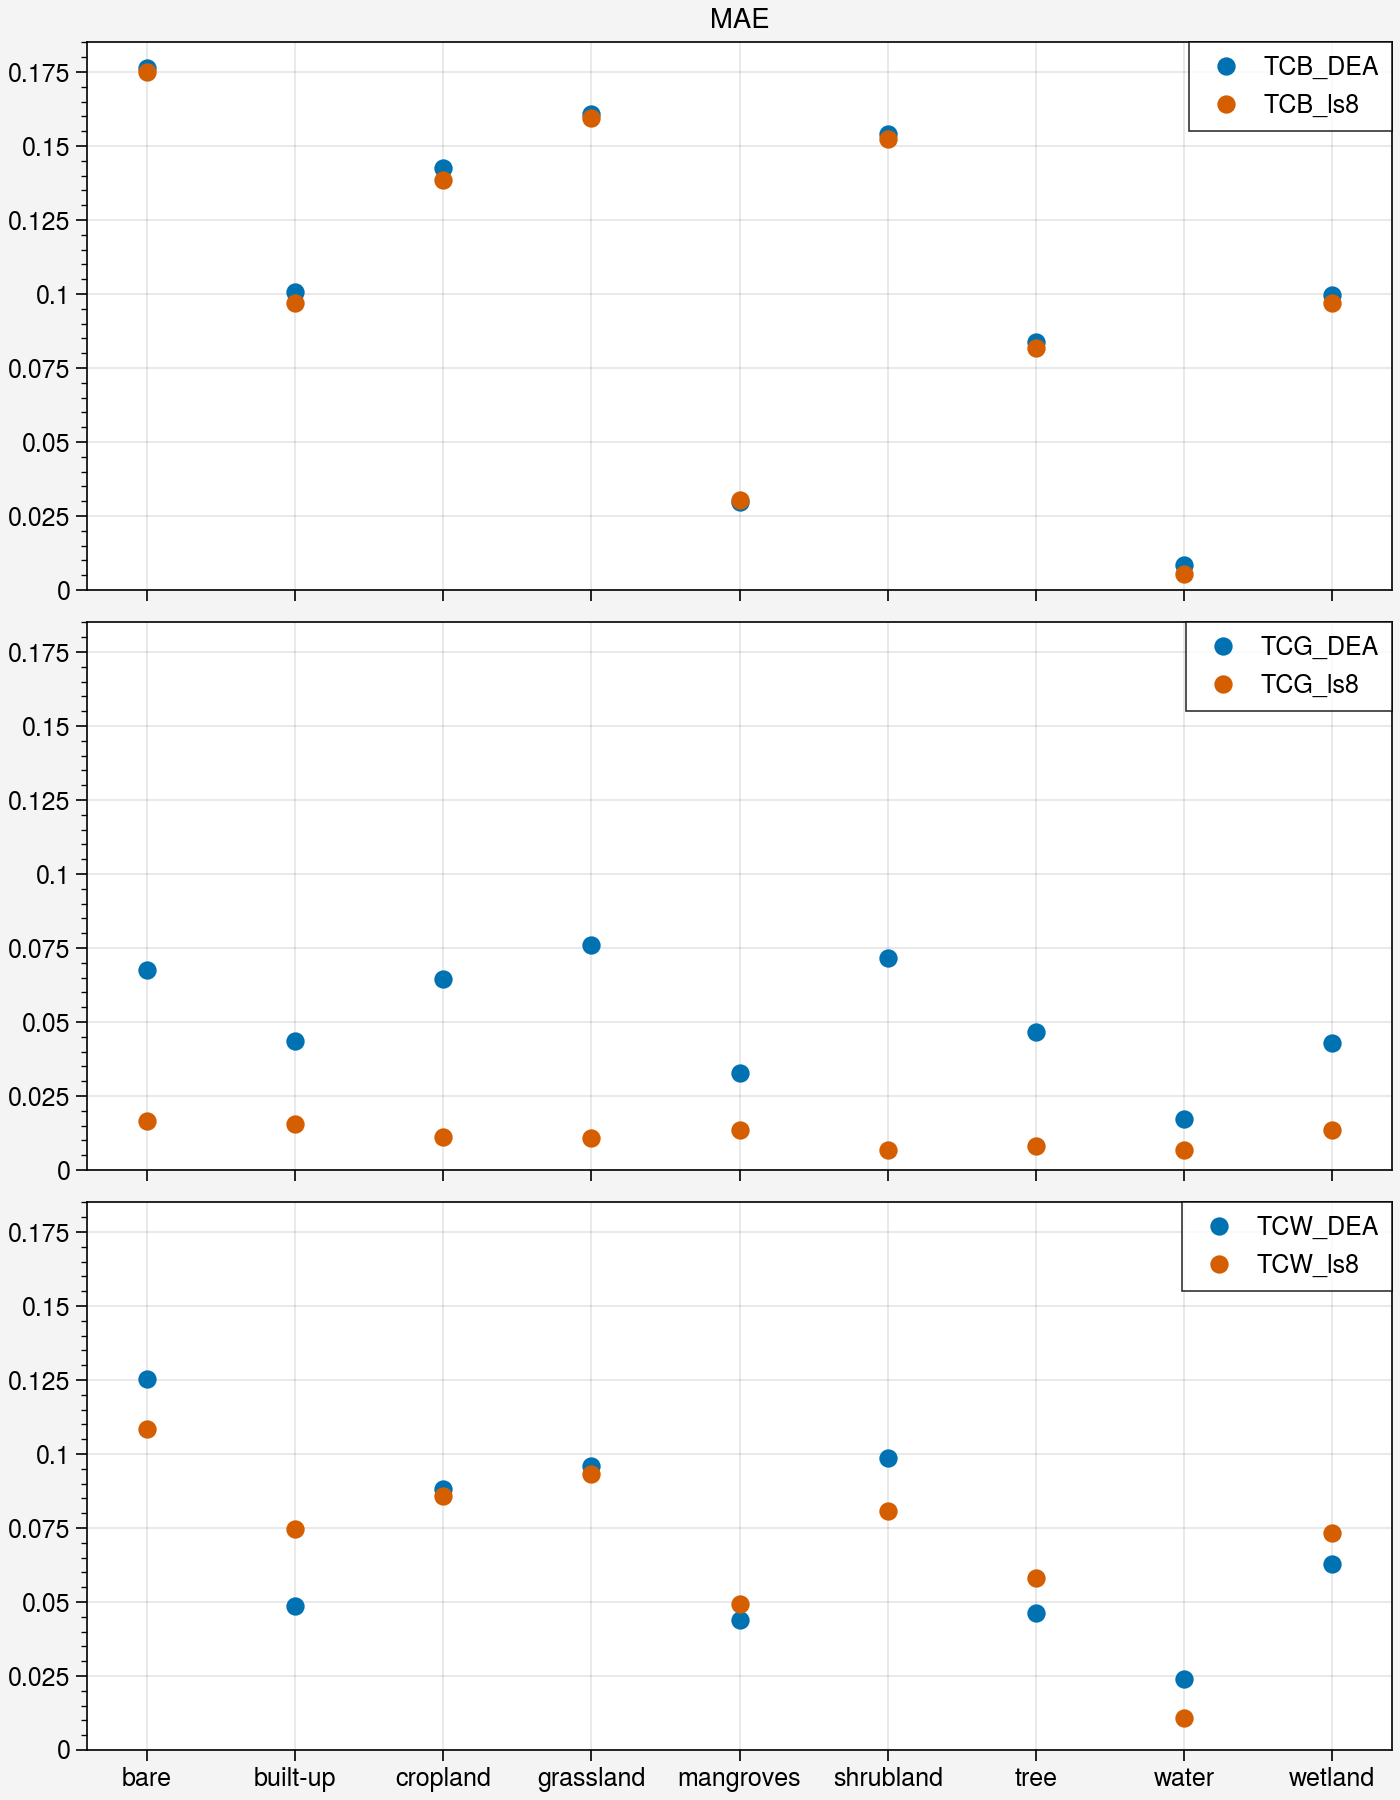

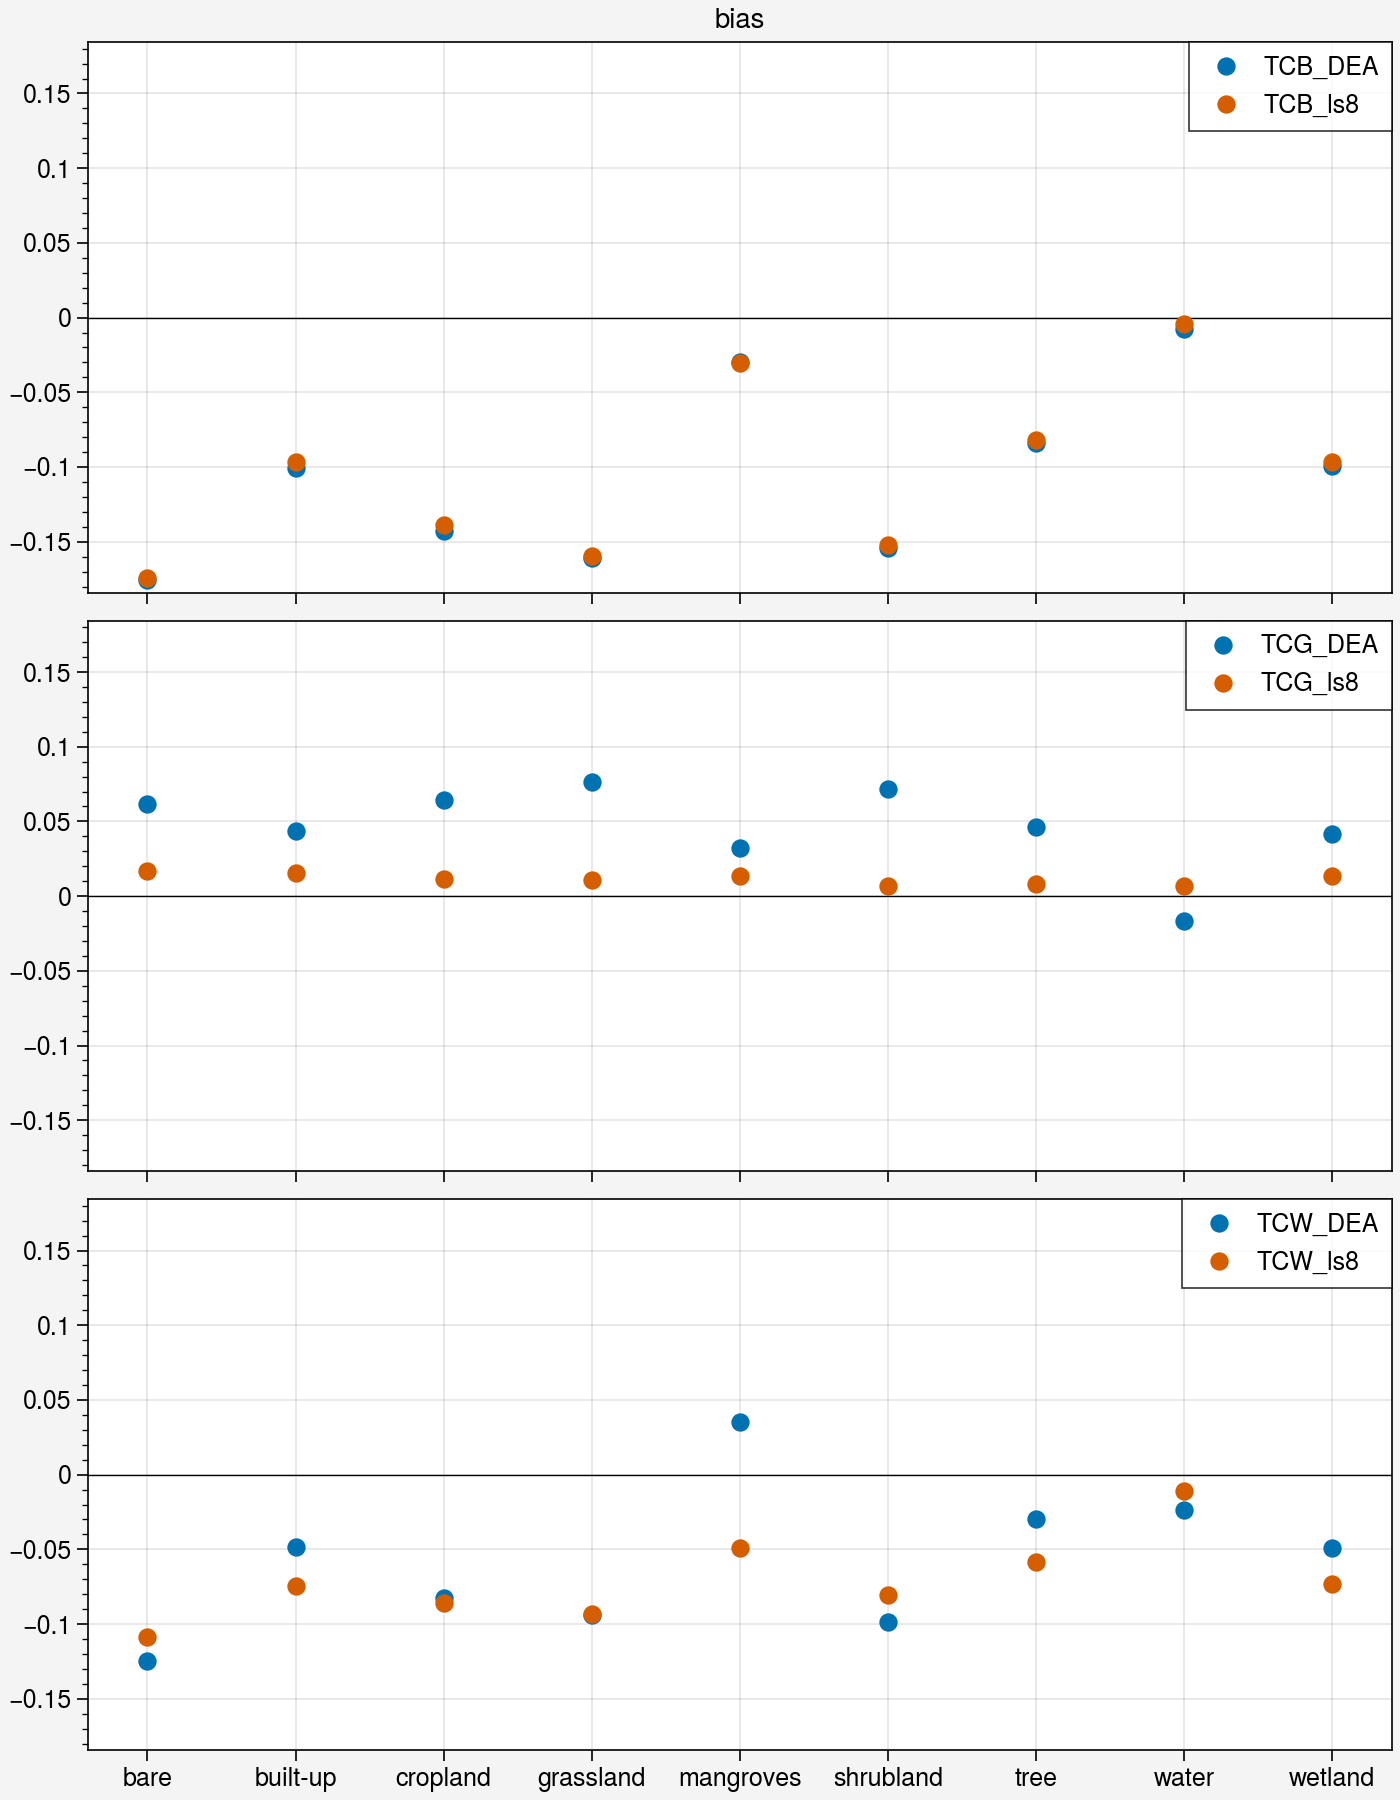

In [15]:
for metric in ['RMSE', 'MAE', 'bias']:
    f, axs = plt.subplots(3, 1, figsize=(7, 9), layout='constrained', sharex=True)
    # colors = iter([plt.cm.tab10(i) for i in range(6)])
    for i, (name, group) in enumerate(error_metrics_df.groupby('TC')):
        axs[i // 2].scatter(np.arange(group.shape[0]), group[metric], label=name, zorder=2)
    y_min = np.min([ax.get_ylim()[0] for ax in axs])
    y_max = np.max([ax.get_ylim()[1] for ax in axs])
    for ax in axs:
        ax.set_xticklabels([''] + list(group['class']))
        ax.xaxis.minorticks_off()
        ax.legend()
        if metric == 'bias':
            ax.set_ylim(-np.max((np.abs(y_min), y_max)),
                        np.max((np.abs(y_min), y_max)))
            ax.axhline(0, c='k', lw=0.5, zorder=1)
        else:
            ax.set_ylim(0, y_max)
        ax.grid(visible=True)
    axs[0].set_title(metric)

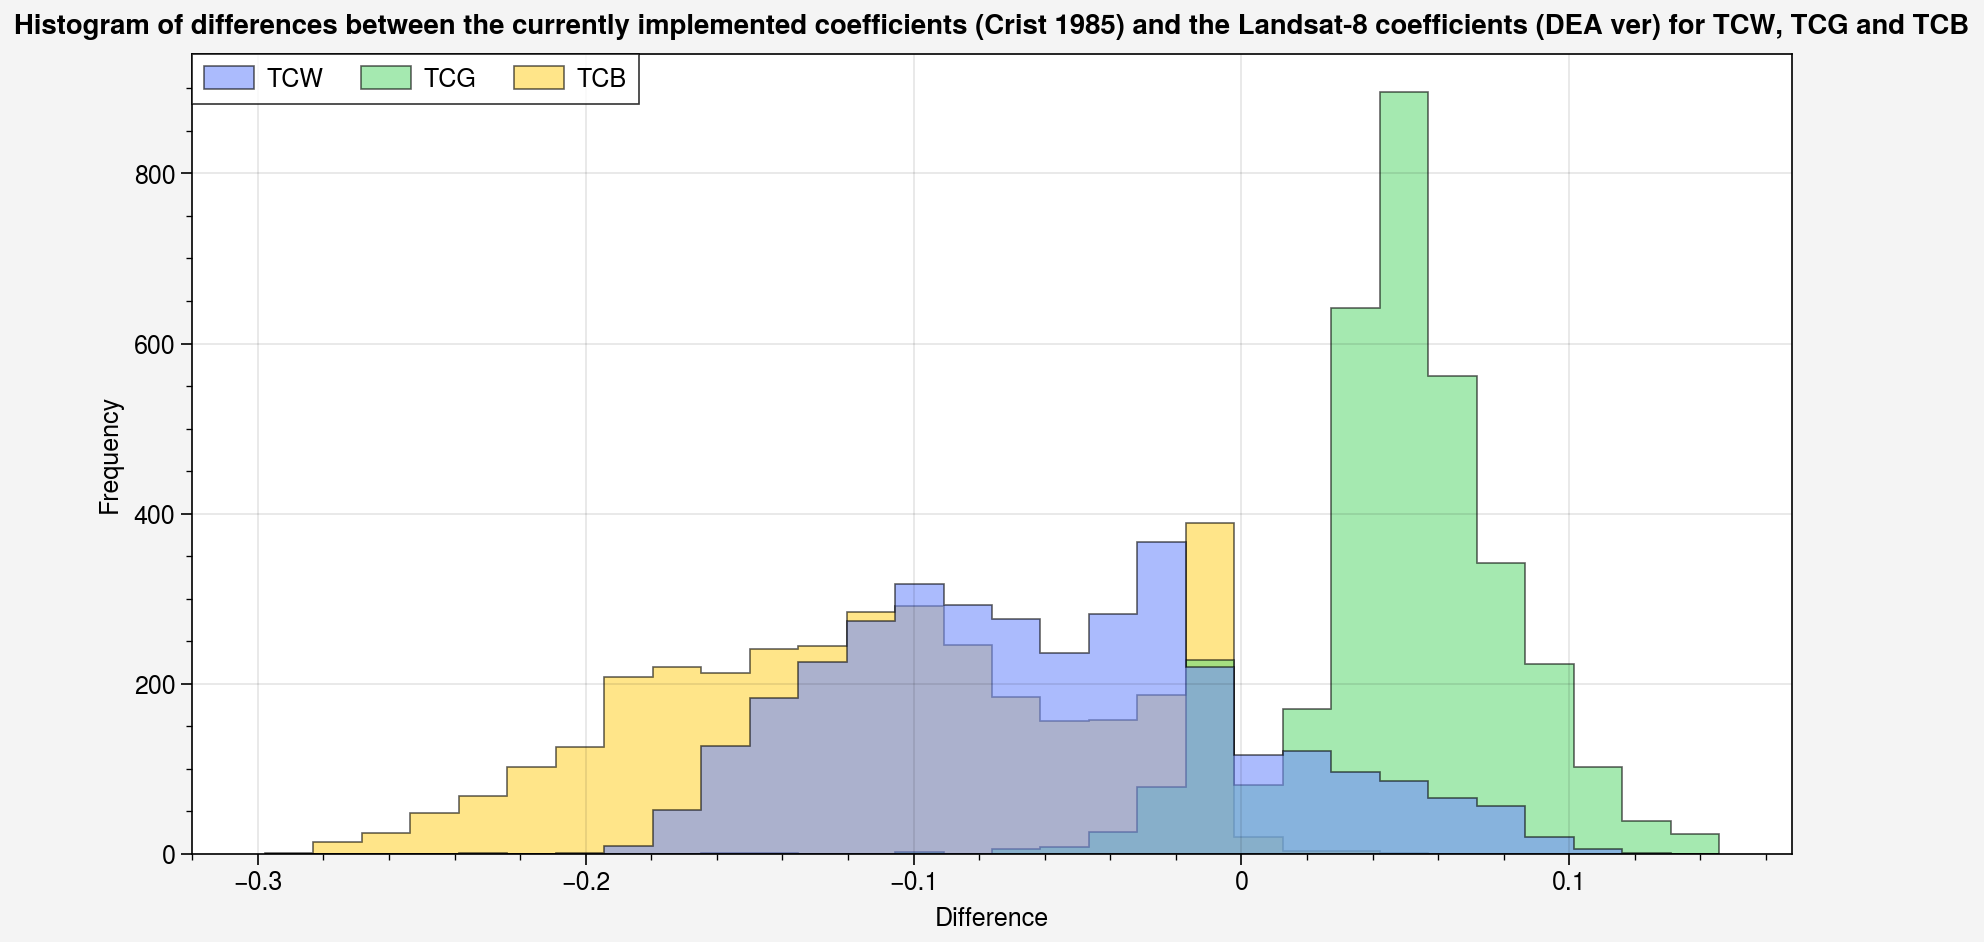

In [16]:
hist_test_dea = cdf[['diff_TCW_DEA', 'diff_TCG_DEA', 'diff_TCB_DEA']]

fig, ax = uplt.subplots(refwidth=8, refaspect=(8,4))
ax.format(suptitle='Histogram of differences between the currently implemented coefficients (Crist 1985) and the Landsat-8 coefficients (DEA ver) for TCW, TCG and TCB', xlabel='Difference', ylabel='Frequency')
res = ax.hist(
    hist_test_dea,
    bins=30,
    histtype='stepfilled',
    filled=True,
    alpha=0.6,
    edgecolor='k',
    cycle=('indigo4', 'green4', 'yellow4'),
    labels=list(['TCW', 'TCG', 'TCB']),
    legend='ul'
    
)


fig.savefig("histogram_tc_diff_dea.png", dpi=100, bbox_inches='tight')
#plt.close()

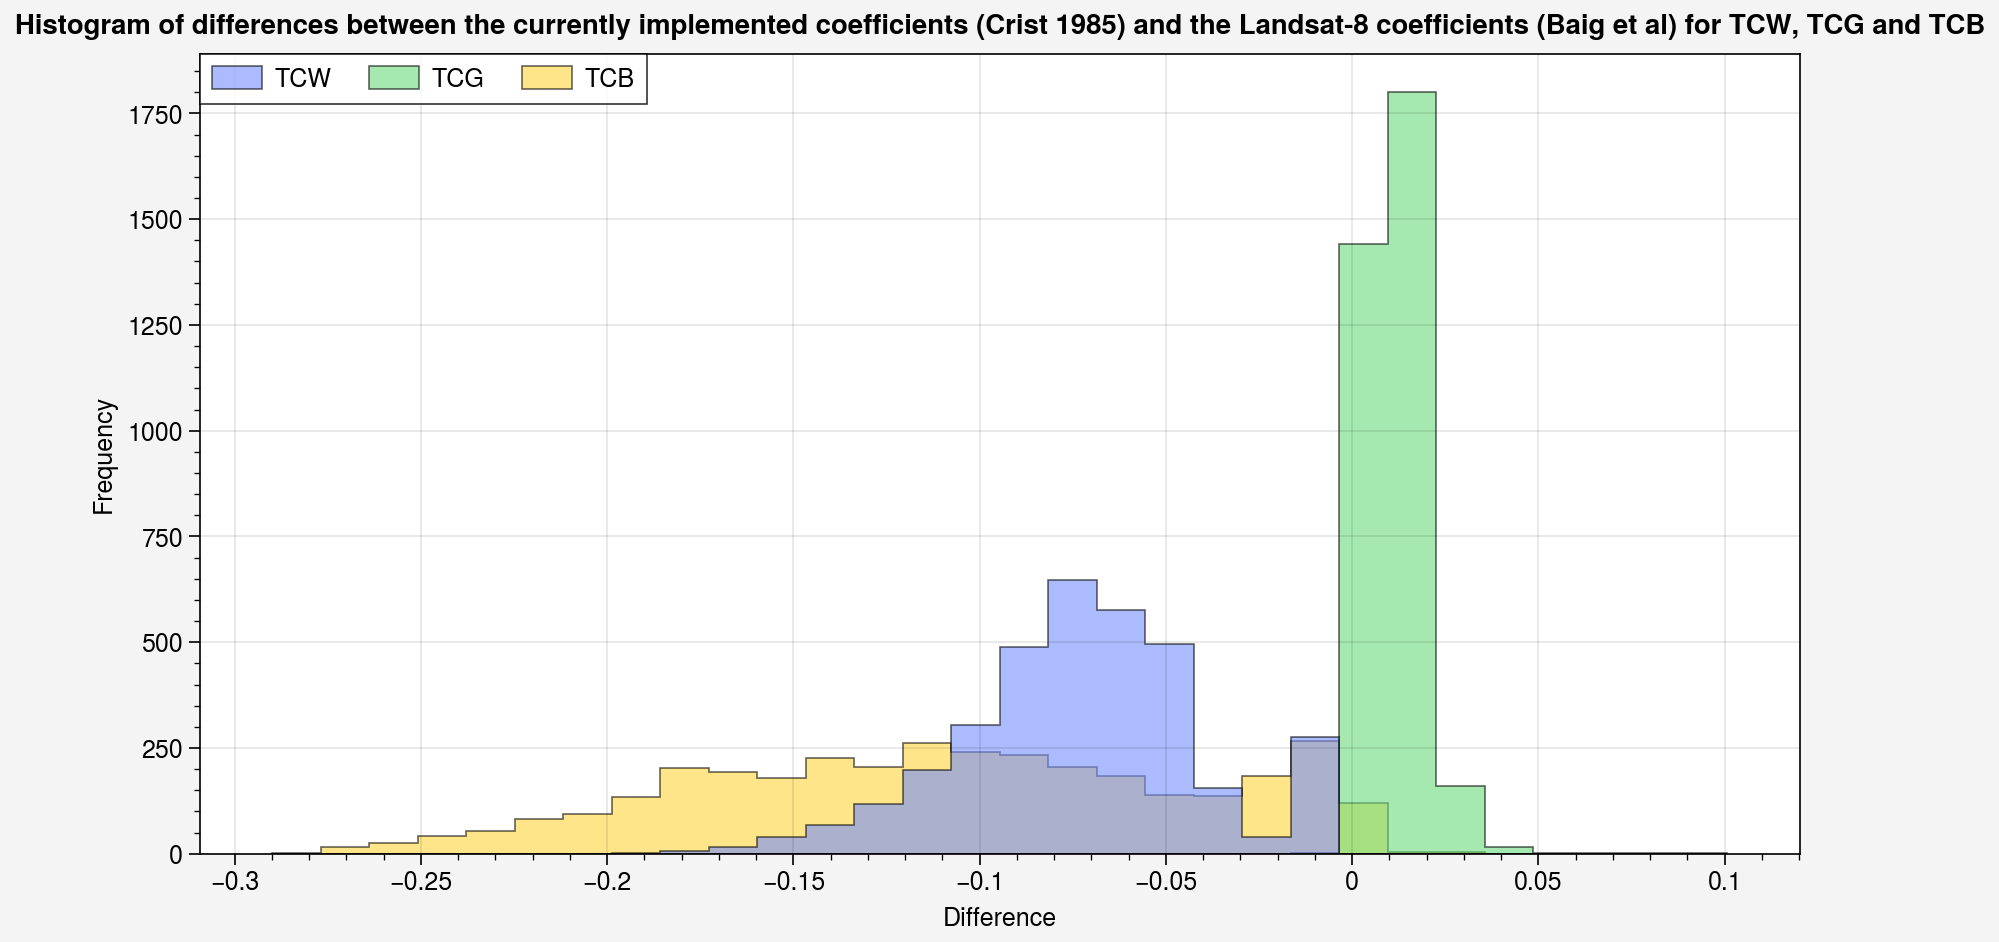

In [17]:
hist_test_baig = cdf[['diff_TCW_ls8', 'diff_TCG_ls8', 'diff_TCB_ls8']]

fig, ax = uplt.subplots(refwidth=8, refaspect=(8,4))
ax.format(suptitle='Histogram of differences between the currently implemented coefficients (Crist 1985) and the Landsat-8 coefficients (Baig et al) for TCW, TCG and TCB', xlabel='Difference', ylabel='Frequency')
res = ax.hist(
    hist_test_baig,
    bins=30,
    histtype='stepfilled',
    filled=True,
    alpha=0.6,
    edgecolor='k',
    cycle=('indigo4', 'green4', 'yellow4'),
    labels=list(['TCW', 'TCG', 'TCB']),
    legend='ul'
    
)

fig.savefig("histogram_tc_diff_baig.png", dpi=100, bbox_inches='tight')
#plt.close()

In [18]:
sub_df = cdf[cdf['classname'].isin(['water', 'mangroves', 'tree'])]
sub_df.head()

,class,TCW,TCG,TCB,TCW_DEA,TCB_DEA,TCG_DEA,TCW_ls8,TCB_ls8,TCG_ls8,classname,diff_TCW_DEA,diff_TCW_ls8,diff_TCG_DEA,diff_TCG_ls8,diff_TCB_DEA,diff_TCB_ls8
1591,95,-0.023103,0.129022,0.186115,-0.077146,0.207077,0.090891,0.022820,0.208181,0.116481,mangroves,0.054043,-0.045923,0.038131,0.012541,-0.020962,-0.022066
1592,95,-0.017345,0.166410,0.212037,-0.094607,0.231694,0.117502,0.036587,0.233638,0.151050,mangroves,0.077262,-0.053932,0.048908,0.015360,-0.019657,-0.021601
1593,95,-0.013405,0.183874,0.231405,-0.102205,0.250541,0.129949,0.045477,0.252578,0.166808,mangroves,0.088800,-0.058882,0.053925,0.017066,-0.019136,-0.021173
1594,95,-0.020565,0.104577,0.149975,-0.061640,0.168403,0.074426,0.017032,0.169026,0.094081,mangroves,0.041075,-0.037597,0.030151,0.010496,-0.018428,-0.019051
1595,95,-0.030717,0.069442,0.169150,-0.044950,0.195673,0.050800,0.008755,0.194939,0.057931,mangroves,0.014233,-0.039472,0.018642,0.011511,-0.026523,-0.025789


In [20]:

# g = sns.PairGrid(sub_df, vars=['water', 'mangroves', 'tree'], hue='classname', corner=True)
# g.map_diag(sns.histplot,  color='0.3') #multiple='stack', element='step',
# g.map_offdiag(sns.scatterplot, marker='.')
# g.add_legend()

# g.savefig("pairgrid_tc_current_coefs.png", dpi=100, bbox_inches='tight')
# #plt.close()

In [21]:
# g = sns.PairGrid(wetland_mangroves_water_df, vars=['TCW_DEA', 'TCG_DEA', 'TCB_DEA'], hue='classname', corner=True)
# g.map_diag(sns.histplot,  color='0.3') #multiple='stack', element='step',
# g.map_offdiag(sns.scatterplot, marker='.')
# g.add_legend()

# g.savefig("pairgrid_tc_dea_coefs.png", dpi=100, bbox_inches='tight')
# #plt.close()

In [22]:
# g = sns.PairGrid(wetland_mangroves_water_df, vars=['TCW_ls8', 'TCG_ls8', 'TCB_ls8'], hue='classname', corner=True)
# g.map_diag(sns.histplot,  color='0.3') #multiple='stack', element='step',
# g.map_offdiag(sns.scatterplot, marker='.')
# g.add_legend()

# g.savefig("pairgrid_tc_baig_coefs.png", dpi=100, bbox_inches='tight')
# #plt.close()

In [23]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

combined_no_water_df = cdf[~cdf['classname'].isin(['water'])]

classes = list(combined_no_water_df['classname'].unique())
bandwidth = 0.5 #modified the 'smoothing' of the kde

darkgreen = '#9BC184'
midgreen = '#C2D6A4'
lightgreen = '#E7E5CB'
colors = [lightgreen, midgreen, darkgreen, midgreen, lightgreen]

darkgrey = '#525252'

variable_diffs = ['diff_TCW_DEA', 'diff_TCG_DEA', 'diff_TCB_DEA']

In [28]:
# cel working on iterating the figs instead of copying them

for var in variable_diffs:
    fig, axs = plt.subplots(nrows = len(classes), ncols=1, figsize=(8,12), sharex=True, layout='constrained')
    axs = axs.flatten()
    
    diff_df = combined_no_water_df[[var, 'classname']]
    x_min = min(diff_df[var])
    x_max = max(diff_df[var])

    for i, cls in enumerate(classes):
        subset = diff_df[diff_df['classname'] == cls]
    
        sns_kde = sns.kdeplot(
            subset[var],
            shade=True,
            bw_adjust = bandwidth,
            ax = axs[i],
            fill=True,
            alpha=0.3,
            linewidth=1,
            color='grey',
            edgecolor='k'
        )
    y_max = np.max([ax.get_ylim()[1] for ax in axs])
    for i, cls in enumerate(classes):
        subset = diff_df[diff_df['classname'] == cls]
    
        axs[i].set_ylim(0, y_max)
        # quantiles
        quantiles = np.percentile(subset[var], [2.5, 10, 25, 75, 90, 97.5])
        quantiles = list(quantiles)
    
        # fill space between each pair of quantiles
        for j in range(len(quantiles) - 1):
            axs[i].fill_between(
                [quantiles[j],
                quantiles[j + 1]],
                0,
                (0.1 * y_max),
                color=colors[j],
                alpha=0.8
            )
    
        #add mean value as reference
        mean = subset[var].mean()
        axs[i].scatter([mean], [0.05 * y_max], color='black', s=15)
    
        #title and labels
        axs[i].set_xlim(x_min, x_max)
        axs[i].set_ylabel(
            cls.upper(), 
            fontdict={'fontsize': 10, 'fontweight': 'bold', 'color': darkgrey}, 
            rotation=0,
            labelpad=80,
            ha='left')
        axs[i].set_xlabel('Distribution')
        
    # # legend on the first ax
    # subax = inset_axes(
    #     parent_axes=axs[0],
    #     width="30%",
    #     height="90%",
    #     loc=1
    # )
    # subax.set_xticks([])
    # subax.set_yticks([])
    
    # legend_subset = diff_df[diff_df['classname'] == 'grassland']
    
    # sns.kdeplot(
    #     legend_subset[var],
    #     shade=True,
    #     ax=subax,
    #     color='grey',
    #     edgecolor='lightgrey'
    # )
    # quantiles = np.percentile(legend_subset[var], [2.5, 10, 25, 75, 90, 97.5])
    # quantiles = quantiles.tolist()
    # for j in range(len(quantiles) - 1):
    #     subax.fill_between(
    #         [quantiles[j], # lower bound
    #          quantiles[j+1]], # upper bound
    #         0, # max y=0
    #         2, # max y=0.00004
    #         color=colors[j]
    #     )
    # subax.set_xlim(x_min, x_max)
    # mean = legend_subset[var].mean()
    # subax.scatter([mean], [2], color='black', s=10)
    
    # subax.text(
    #     -0.13, 20,
    #     'Legend',
    #     ha='left',
    #     fontsize=12,
    # )
    
    
    # subax.text(
    #     mean+0.01, 5,
    #     'Mean',
    #     ha='center',
    #     fontsize=7,
    # )
    
    # subax.text(
    #     0.01, -7,
    #     "95%",
    #     ha='center',
    #     fontsize=6,
    # )
    
    # subax.text(
    #     -0.05, -7,
    #     "80%",
    #     ha='center',
    #     fontsize=6,
    # )
    # subax.text(
    #     -0.15, -8,
    #     "50% values\n within this range",
    #     ha='center',
    #     fontsize=6,
    # )
    
    # add_arrow((mean, 0), (mean - 0.02, -5), subax) #50%
    # add_arrow((mean+ 0.03, 0), (mean + 0.04, -5), subax) #80%
    # add_arrow((mean+0.07, 0), (mean + 0.09, -5), subax) #95%
    
    
    fig.suptitle(f'TEST_{var}')
    fig.savefig(f"TEST_{var}.png", dpi=100, bbox_inches='tight')
    plt.close()

In [29]:
# for TWC, scatterplot of the 2 coefficients, with all points in light grey and the class in a bright colour
variable_pairs = [("TCW", "TCW_DEA"), ("TCG", "TCG_DEA"), ("TCB", "TCB_DEA")]

pal = sns.cubehelix_palette(8, rot=-10, light=.6, hue=1, dark=0.3)

fig, axs = plt.subplots(nrows= len(classes), ncols=3, figsize=(10,18), layout='constrained')

for i, (var1, var2) in enumerate(variable_pairs):
    column_name = var1

    data1 = cdf[var1]
    data2 = cdf[var2]

    
    # Set column title at the top row
    axs[0, i].set_title(f"{var1} vs {var2}", fontdict={'fontsize': 12, 'fontweight': 'bold', 'color': darkgrey})


    for row, cls in enumerate(classes):
        ax = axs[row,i]
        color = pal[row]

        class_data = cdf[cdf['classname'] == cls]
        x = class_data[var1].values.reshape(-1,1)
        y = class_data[var2].values

        ax.scatter(data1, data2, color='lightgrey', marker='o', s=0.3, alpha=0.5)
        ax.scatter(x, y, color=color, marker='o', s=0.5)
        ax.set_box_aspect(1)


        if len(x) >1:
            model = LinearRegression()
            model.fit(x, y)
            r2 = model.score(x, y)
            ax.text(0.1, 0.8, 
                    f'$R^2$: {r2:.4f}', 
                    fontsize=8,
                    transform=ax.transAxes)

    
        # Add axis labels
        ax.set_xlabel(var1, fontsize=8)
        ax.set_ylabel(var2, fontsize=8)

            

    # Add class labels on the far left of each row
    for row, (cls, ax_row) in enumerate(zip(classes, axs)):
        ax_row[0].annotate(cls.upper(), 
                           xy = (0, 0.5),
                           xytext=(-0.55, 0.5),
                           xycoords='axes fraction',
                           textcoords='axes fraction',
                           fontsize=10, fontweight='bold', color=darkgrey,
                           ha='right', va='center',
                           annotation_clip=False)

        

fig.suptitle('distribution of TC indices, implenented vs dea unimplemented')
fig.savefig("scatter_plots_esa_worldcover_tc_implemented_vs_dea.png", dpi=100, bbox_inches='tight')
plt.close()


In [30]:
# for TWC, scatterplot of the 2 coefficients, with all points in light grey and the class in a bright colour
variable_pairs = [("TCW", "TCW_ls8"), ("TCG", "TCG_ls8"), ("TCB", "TCB_ls8")]

pal = sns.cubehelix_palette(8, rot=-10, light=.6, hue=1, dark=0.3)

fig, axs = plt.subplots(nrows= len(classes), ncols=3, figsize=(10,18), layout='constrained')

for i, (var1, var2) in enumerate(variable_pairs):
    column_name = var1

    data1 = cdf[var1]
    data2 = cdf[var2]

    
    # Set column title at the top row
    axs[0, i].set_title(f"{var1} vs {var2}", fontdict={'fontsize': 12, 'fontweight': 'bold', 'color': darkgrey})


    for row, cls in enumerate(classes):
        ax = axs[row,i]
        color = pal[row]

        class_data = cdf[cdf['classname'] == cls]
        x = class_data[var1].values.reshape(-1,1)
        y = class_data[var2].values

        ax.scatter(data1, data2, color='lightgrey', marker='o', s=0.3, alpha=0.5)
        ax.scatter(x, y, color=color, marker='o', s=0.5)
        ax.set_box_aspect(1)


        if len(x) >1:
            model = LinearRegression()
            model.fit(x, y)
            r2 = model.score(x, y)
            ax.text(0.1, 0.8, 
                    f'$R^2$: {r2:.4f}', 
                    fontsize=8,
                    transform=ax.transAxes)

    
        # Add axis labels
        ax.set_xlabel(var1, fontsize=8)
        ax.set_ylabel(var2, fontsize=8)

            

    # Add class labels on the far left of each row
    for row, (cls, ax_row) in enumerate(zip(classes, axs)):
        ax_row[0].annotate(cls.upper(), 
                           xy = (0, 0.5),
                           xytext=(-0.55, 0.5),
                           xycoords='axes fraction',
                           textcoords='axes fraction',
                           fontsize=10, fontweight='bold', color=darkgrey,
                           ha='right', va='center',
                           annotation_clip=False)

        

fig.suptitle('distribution of TC indices, implenented vs Baig et al 2014')
fig.savefig("scatter_plots_esa_worldcover_tc_implemented_vs_baig.png", dpi=100, bbox_inches='tight')
plt.close()

In [31]:
cdf.head()

,class,TCW,TCG,TCB,TCW_DEA,TCB_DEA,TCG_DEA,TCW_ls8,TCB_ls8,TCG_ls8,classname,diff_TCW_DEA,diff_TCW_ls8,diff_TCG_DEA,diff_TCG_ls8,diff_TCB_DEA,diff_TCB_ls8
0,40,-0.343292,0.015310,0.334093,-0.186755,0.528521,-0.054765,-0.250793,0.518441,0.007040,cropland,-0.156537,-0.092499,0.070075,0.008270,-0.194428,-0.184348
1,40,-0.335815,0.055465,0.339959,-0.209164,0.530078,-0.029725,-0.239276,0.521131,0.046413,cropland,-0.126651,-0.096539,0.085190,0.009052,-0.190119,-0.181172
2,40,-0.303964,0.039052,0.332728,-0.170835,0.498799,-0.017462,-0.220038,0.492230,0.032349,cropland,-0.133129,-0.083926,0.056514,0.006703,-0.166071,-0.159502
3,40,-0.310137,0.052373,0.420295,-0.178643,0.591218,-0.002329,-0.211767,0.586026,0.041634,cropland,-0.131494,-0.098370,0.054702,0.010739,-0.170923,-0.165731
4,40,-0.342098,0.018366,0.329182,-0.206729,0.518070,-0.063427,-0.251150,0.513022,0.011868,cropland,-0.135369,-0.090948,0.081793,0.006498,-0.188888,-0.183840


In [96]:
from sklearn import datasets

iris = datasets.load_iris()
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [100]:
# try and do a PCA thingy

# nd array of TC original + class numbers

class_np = cdf[['class']].to_numpy().flatten()
tc_np = cdf[['TCW', 'TCG', 'TCB']].to_numpy()
tc_dea_np = cdf[['TCW_DEA', 'TCG_DEA', 'TCB_DEA']].to_numpy()


target_names = np.array(worldcover_class_list)

tc_np.shape

(3428, 3)

In [101]:
target_names

array(['cropland', 'grassland', 'wetland', 'shrubland', 'mangroves',
       'water', 'built-up', 'bare', 'tree'], dtype='<U9')

In [102]:
X = tc_np
y = class_np


pca = PCA(n_components=2)
X_r = pca.fit(X).transform(X)

In [104]:
X_r

array([[ 0.14203681, -0.08593856],
       [ 0.13891303, -0.06359352],
       [ 0.11250244, -0.05273646],
       ...,
       [-0.08612022, -0.00585306],
       [-0.10137069, -0.00167453],
       [-0.00538586,  0.00070587]])

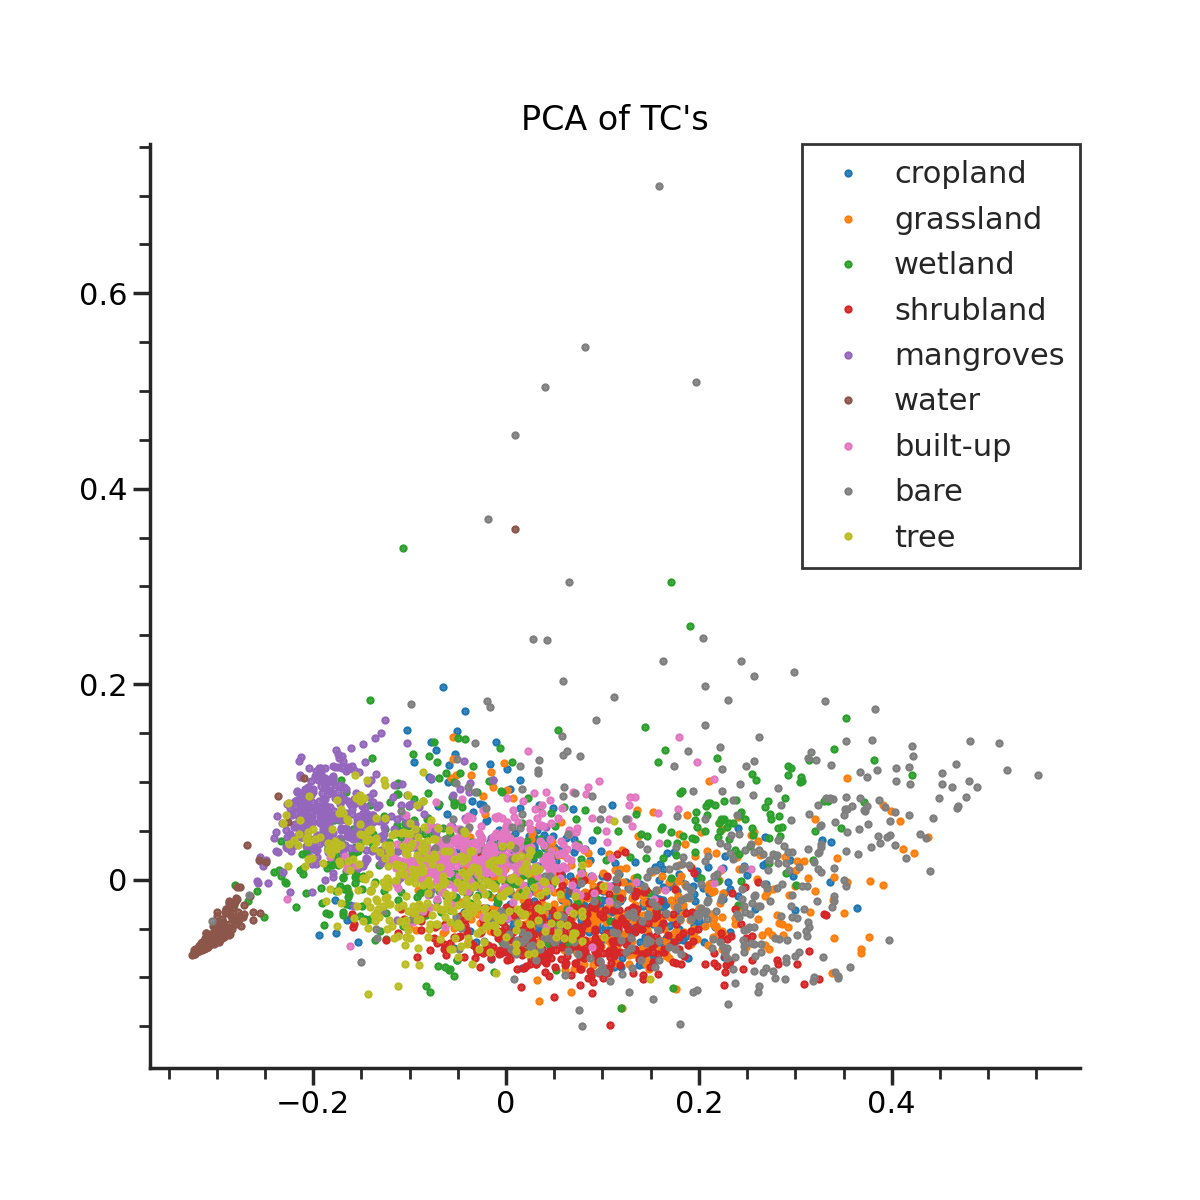

In [108]:
plt.figure(figsize = (6,6))
colors = iter([plt.cm.tab10(i) for i in range(9)])
# colors = ['k', 'red', 'blue', 'green', 'cyan', 'magenta', 'yellow', 'darkorange', 'navy']
lw = 2

for i, target_name in zip(cdf['class'].unique(), target_names):
    plt.scatter(
        X_r[y == i, 0], X_r[y == i, 1], color=[next(colors)], lw=lw,  label=target_name, s=1)
    plt.legend(loc='best', scatterpoints=1)
    plt.title("PCA of TC's")
    
    